In [460]:
import pandas as pd
import numpy as np
import re
import json
import scipy

In [470]:
# Specify the file name
file_name = "data"  # Replace with your file name

# Read the content of the file
with open(file_name, "r") as file:
    data = file.read()


# Pattern to match ${A..} and ${B..} blocks
pattern = r"\$\{([AB]\d+:[^}]+)\}"

# Extract matches using regex
matches = re.findall(pattern, data)

# Process and categorize the matches
data_blocks = {"A": [], "B": []}
for match in matches:
    if match.startswith("A"):
        data_blocks["A"].append(match)
    elif match.startswith("B"):
        data_blocks["B"].append(match)

# Function to parse individual entries (e.g., A0:0:7:86)
def parse_entry(entry):
    parts = entry.split(":")
    # Clean and convert values
    clean = lambda x: int(x.replace("‑", "-").replace("−", "-"))  # Replace non-standard hyphens
    if len(parts) == 4:
        key, start, length, value = parts
        return {"Encoder1": key[1:], "Encoder2": clean(start), "Voltage": clean(length), "phi": clean(value)}
    elif len(parts) == 3:
        key, start, value = parts
        return {"phi":key[1:], "phi_dot": clean(start), "Servo": clean(value)}
    else:
        return {"raw_entry": entry}  # Fallback for unexpected formats

# Parse data for A and B blocks
parsed_data = {"A": [parse_entry(entry) for entry in data_blocks["A"]],
               "B": [parse_entry(entry) for entry in data_blocks["B"]]}

# Example: Output the processed data
print("Parsed A data:")
for item in parsed_data["A"]:
    print(item)

print("\nParsed B data:")
for item in parsed_data["B"]:
    print(item)

# Optionally, save to a file
with open("parsed_data.json", "w") as f:
    import json
    json.dump(parsed_data, f, indent=4)

# Further processing can be added as needed


Parsed A data:
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 6, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}
{'Encoder1': '0', 'Encoder2': 0, 'Voltage': 7, 'phi': 86}

In [471]:
# Load the JSON file
json_file = "parsed_data.json"  # Ensure this is the correct path to your JSON file

with open(json_file, "r") as f:
    data = json.load(f)

# Convert the "A" and "B" blocks to pandas DataFrames
df_a = pd.DataFrame(data["A"], columns=["Encoder1", "Encoder2", "Voltage", "phi"], dtype=float)
df_b = pd.DataFrame(data["B"], columns=["phi", "phi_dot", "Servo"], dtype=float)

# Display the DataFrames
print("DataFrame for A Block:")
print(df_a)

print("\nDataFrame for B Block:")
print(df_b)

# Save as CSV for further analysis if needed
df_a.to_csv("parsed_A_data.csv", index=False)
df_b.to_csv("parsed_B_data.csv", index=False)


## Don't normalise, but fix to radians
MID = 750
delta = (df_b['Servo'] - MID) / 3.65
df_b['delta'] = delta


# df_b['delta'] = df_b['delta'] / 180 * np.pi
# df_b['phi_rad'] = df_b['phi'] / 180 * np.pi
# df_b['phi_dot'] = df_b['phi_dot'] / 180 * np.pi

DataFrame for A Block:
     Encoder1  Encoder2  Voltage   phi
0         0.0       0.0      7.0  86.0
1         0.0       0.0      7.0  86.0
2         0.0       0.0      7.0  86.0
3         0.0       0.0      6.0  86.0
4         0.0       0.0      6.0  86.0
..        ...       ...      ...   ...
829       0.0       0.0      0.0  23.0
830       0.0       0.0      0.0  23.0
831       0.0       0.0      0.0  25.0
832       0.0       0.0      0.0  22.0
833       0.0       0.0      0.0  21.0

[834 rows x 4 columns]

DataFrame for B Block:
      phi  phi_dot  Servo
0    86.0      0.0  751.0
1    86.0      0.0  752.0
2    86.0      1.0  751.0
3    86.0      0.0  751.0
4    86.0      0.0  751.0
..    ...      ...    ...
574  21.0     51.0  631.0
575  25.0      9.0  631.0
576  24.0     20.0  631.0
577  23.0    -14.0  631.0
578  22.0      1.0  631.0

[579 rows x 3 columns]


<Axes: ylabel='Frequency'>

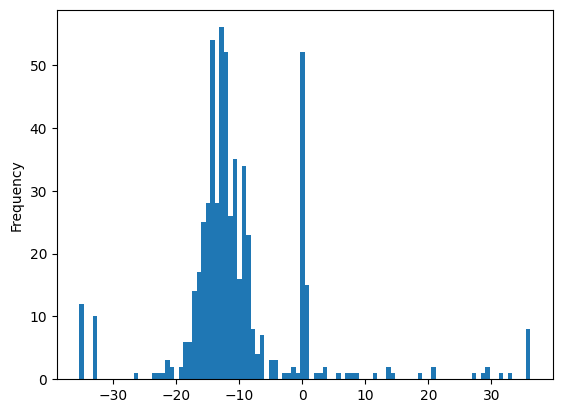

In [481]:
delta.plot.hist(bins=100) #   -35 < delta < 36
# (df_b['delta']).plot.hist(bins=100)
# df_b['phi_dot'].plot.hist(bins=50)

<Axes: ylabel='Frequency'>

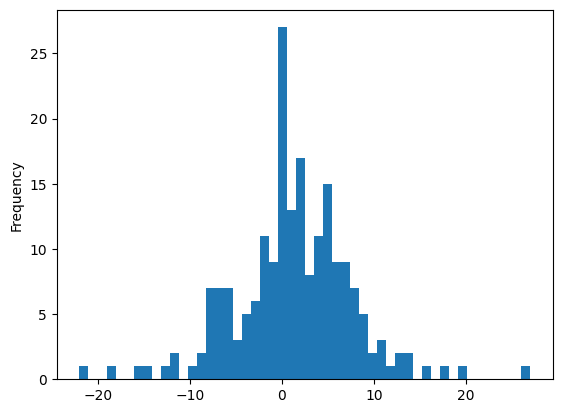

In [495]:
clean_states = df_b[df_b['phi'].abs() <= 45][100:300]
# clean_states = clean_states.drop(columns=['phi', 'Servo'])[['phi_rad', 'phi_dot', 'delta']]
clean_states = clean_states.drop(columns=['Servo'])[['phi', 'phi_dot', 'delta']]
# clean_states
clean_states['phi_dot'].plot.hist(bins=50)

In [496]:
# matlab_states_x_g = pd.Series([val for pair in zip(clean_states['phi_rad'], clean_states['phi_dot'], clean_states['delta']) for val in pair])
matlab_states_x_g = pd.Series([val for pair in zip(clean_states['phi'], clean_states['phi_dot'], clean_states['delta']) for val in pair])
matlab_states_x_g

0       0.000000
1      -8.000000
2     -16.164384
3       0.000000
4       0.000000
         ...    
595    12.000000
596    -8.767123
597     0.000000
598    -7.000000
599   -15.890411
Length: 600, dtype: float64

In [497]:
# # Compute phi dot
# Ts = 0.020
# for i in range(1, len(clean_states)):
#     clean_states['phi_dot'].iloc[i] = (clean_states['phi_rad'].iloc[i] - clean_states['phi_rad'].iloc[i-1]) / Ts


# # clean_states['phi_dot'] = clean_states['phi_rad'].diff()
# # clean_states['phi_dot'] = clean_states['phi_dot'].fillna(0)
# # clean_states['phi_dot'] = clean_states['phi_dot'].shift(-1)
# # clean_states['phi_dot'] = clean_states['phi_dot'].fillna(0) / Ts
# clean_states['phi_dot'].unique()

In [498]:
# Compute phi dot
Ts = 0.020
clean_states['phi_dot'] = clean_states['phi'].diff()
clean_states['phi_dot'] = clean_states['phi_dot'].fillna(0)
clean_states['phi_dot'] = clean_states['phi_dot'].shift(-1)
clean_states['phi_dot'] = clean_states['phi_dot'].fillna(0) / Ts
clean_states['phi_dot'].unique()

array([0.])

In [499]:
# Compute delta dot for u_g
Ts = 0.020
clean_states['delta_dot'] = clean_states['delta'].diff()
clean_states['delta_dot'] = clean_states['delta_dot'].fillna(0)
clean_states['delta_dot'] = clean_states['delta_dot'].shift(-1)
clean_states['delta_dot'] = clean_states['delta_dot'].fillna(0) / Ts
matlab_inputs_u_g = clean_states['delta_dot']
matlab_inputs_u_g = clean_states['delta']
clean_states


,phi,phi_dot,delta,delta_dot
157,0.0,0.0,-16.164384,150.684932
158,0.0,0.0,-13.150685,178.082192
159,0.0,0.0,-9.589041,41.095890
160,0.0,0.0,-8.767123,-232.876712
161,0.0,0.0,-13.424658,205.479452
...,...,...,...,...
352,0.0,0.0,-12.054795,-68.493151
353,0.0,0.0,-13.424658,205.479452
354,0.0,0.0,-9.315068,27.397260
355,0.0,0.0,-8.767123,-356.164384


In [500]:
matlab_data = {'x_g': matlab_states_x_g, 'u_g': matlab_inputs_u_g}
scipy.io.savemat('matlab_data.mat', matlab_data, oned_as='column')

In [514]:
from scipy.signal import cont2discrete, lti, dlti, dstep
epsilon = 0

# Bike data
g = 9.8
h = 0.088 # m (hieght of the centre of mass)
v = 0.634 # m/s or v = 0.634
a = 0.055 # m (distance between rear wheel and centre of gravity projection)
w = 0.167 # m (Distance between front and rear wheels and ground contact points)
lambd =  75/180 * np.pi # in rad = 70 degrees  (fork angle)
wheel_radius = 0.0375 # m (diameter is around 7.5cm)
r_tau = wheel_radius * np.tan(np.pi/2 - lambd) # (distance between front wheel and intersection of fork with ground)
l = w; # length

A23 = -(v**2*h-a*r_tau*g) * np.sin(lambd) / (h**2*l);
B2 = - a*v*np.sin(lambd)/(h*l) # Try with negative: yes

A_c = [[0,   1,   0],
      [g/h,  0,  A23],
       [0,   0,   0]]
B_c = [[0],
       [B2],
       [1]]
sys = cont2discrete((A_c, B_c, np.ndarray([[1, 0, 0]]), 0), 0.02)
A_s = sys[0]
B_s = sys[1]
A_s = np.array([[1.0224, 0.0201, -0.0045],
                [2.2438, 1.0224, -0.4508],
                [0, 0, 1]])
B_s = np.array([[-0.0005],
                [-0.0507],
                [0.0200]])


# N = size(x_g,1)/3;
# epsilon = 0;
# for i = 2:N-1
#     i
#     current_state = x_g(3*i+1:3*i+3);

#     predict = sysd.A*x_g(3*(i-2)+1:3*(i-2)+3) + sysd.B*u_g(i-1);
#     error = x_g(i+1) - sysd.A*x_g(3*(i-2)+1:3*(i-2)+3) - sysd.B*u_g(i-1);
#     epsilon = max(norm(error, 2), epsilon);
# end

for i in range(len(clean_states)):
    if i == 0:
        continue
    current_state = clean_states.iloc[i].drop(['delta_dot']).to_numpy()[np.newaxis].transpose()
    previous_state = clean_states.iloc[i-1].drop(['delta_dot'])
    predict = (A_s @ previous_state)[np.newaxis].transpose() + B_s * matlab_inputs_u_g.iloc[i-1]
    # predict[1] = np.round(predict[1])
    error = current_state - predict
    # print(error)
    epsilon = max(np.linalg.norm(error, 2), epsilon)
    # if np.linalg.norm(error, 2) > 2:
    # print(np.linalg.norm(error, 2))
        # print("predict:", predict)
        # print("current_state:", current_state)
    # if input() == 'q':
    #     break
epsilon

TypeError: 'list' object cannot be interpreted as an integer

In [493]:
len(clean_states)

100

In [379]:
print(clean_states.max())
print()
print(clean_states.min())


phi_rad       0.750492
phi_dot       2.321288
delta         0.631188
delta_dot    31.081206
dtype: float64

phi_rad       0.000000
phi_dot      -4.572763
delta        -0.616842
delta_dot   -43.513688
dtype: float64
